In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

class DataCenterModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        gpu = torch.device('cuda')
        self.device = gpu
        self.activation = nn.ReLU()
        self.linear1 = nn.Linear(2,32)
        self.linear2 = nn.Linear(32,1)

    def forward(self, x):
        x = self.activation(self.linear1(x))
        x = self.linear2(x)
        return x

def train_model(model,X,Y,epochs=50):
    X = torch.tensor(X).float()
    Y = torch.tensor(Y).float()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    gpu = torch.device('cuda')
    loss_record = []
    batch_size = 32
    criterion = torch.nn.MSELoss()
    for epoch in range(epochs):
        for index in range(len(X)):
            # Grabs our sample from our training data 
            input_x = X[index]
            input_y = Y[index]
            # Runs our sample through our network
            output = model.forward(input_x)
            # Calculates the loss
            loss = criterion(output, input_y)
            # Resets the gradient of the optimizer
            optimizer.zero_grad()
            # Performs the backwards pass, finding dL/dW
            loss.backward()
            loss_record.append(loss.item())
            # Performs one optimizer step
            optimizer.step()
    return model,loss_record

def model_pr_descent(p_init,r_init, model, iterations=100, lr=0.01):
    P_record = []
    R_record = []
    cost_record = []
    input = torch.tensor([p_init,r_init]).float()
    input = torch.autograd.Variable(input, requires_grad=True)
    model.zero_grad()
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    input.to(device)
    model.to(device)
    for _ in range(iterations):
        output = model(input)
        output.backward()
        grad = input.grad
        with torch.no_grad():
            input[0] -= lr * grad[0] # P Update
            input[1] -= lr * grad[1] # R Update
        # stores. why not 
        P_record.append(input[0].item())
        R_record.append(input[1].item())
        cost_record.append(output.item())
    #return input[0].item(),input[1].item() # returns predicted P, R
    return P_record, R_record,cost_record





In [2]:
gd_record_file_list = glob.glob('../aqa_sim_data/realExperiment/GD*')

In [3]:
# tests on one file as the sim

temp_data = pd.read_csv('../aqa_sim_data/realExperiment/GDexp10-w8-util5.csv').to_numpy()
print(temp_data.shape)
# note - Cost Col 2, P col 6, R col 7, Pcoef col 8, Rcoef col 9
cost = temp_data[2:,2]
input = temp_data[2:,6:8]

(597, 26)


c:\Users\qsurfacelaptop\miniconda3\envs\test\lib\site-packages\torch\nn\modules\loss.py:536: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


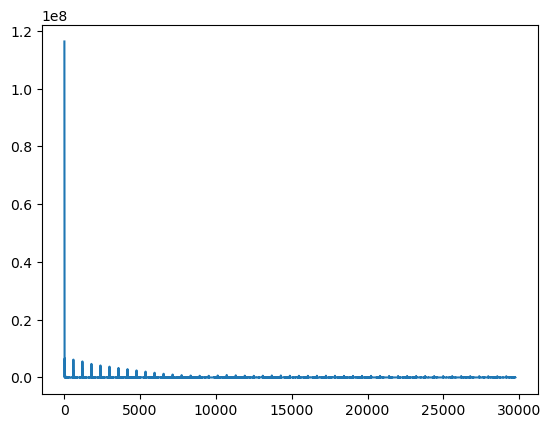

In [4]:
toy_sim_model = DataCenterModel()
toy_sim_model,loss_record = train_model(toy_sim_model,input,cost)
plt.plot(range(len(loss_record[1:])),loss_record[1:])

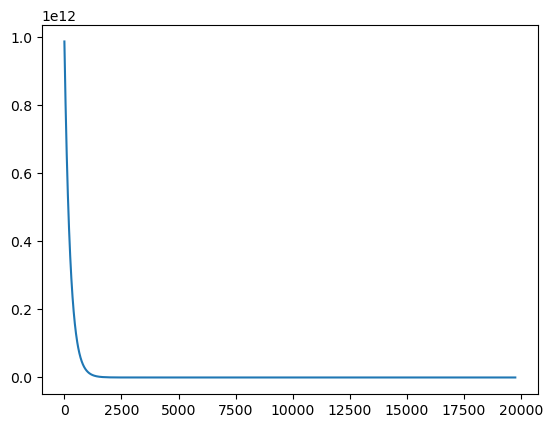

In [169]:
plt.plot(range(len(loss_record[10000:])),loss_record[10000:])

In [12]:
p_bid_steps,r_bid_steps,cost_thing = model_pr_descent(117531,	19818, model=toy_sim_model,iterations=600,lr=1)

In [6]:
print(p_bid_steps[-1],r_bid_steps[-1])

117536.671875 19699.0546875


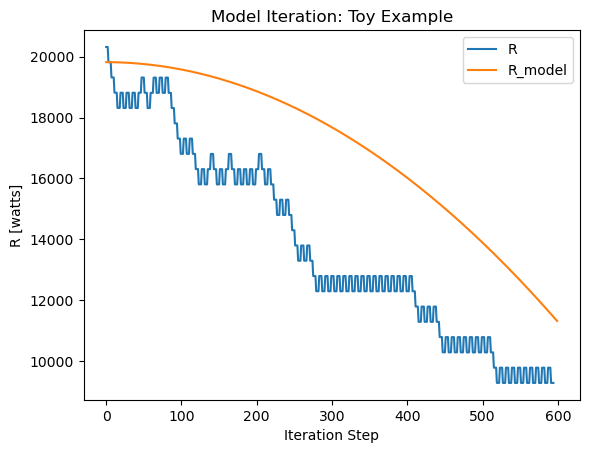

In [15]:
#plt.plot(range(len(input[:,0])),input[:,0],label='P')
plt.plot(range(len(input[:,1])),input[:,1],label='R')
plt.plot((range(len(r_bid_steps))),r_bid_steps,label='R_model')
plt.xlabel('Iteration Step')
plt.ylabel('R [watts]')
plt.title('Model Iteration: Toy Example')
plt.legend()

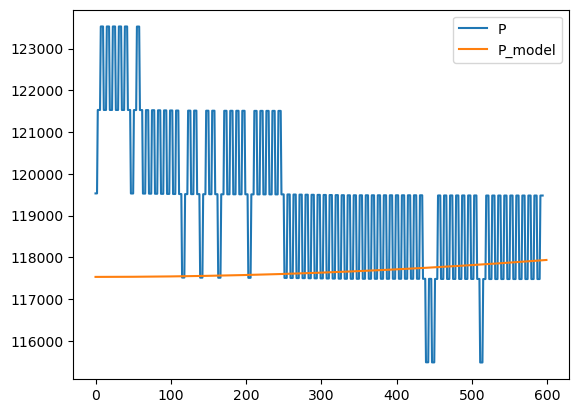

In [14]:
plt.plot(range(len(input[:,0])),input[:,0],label='P')
plt.plot((range(len(p_bid_steps))),p_bid_steps,label='P_model')
plt.legend()

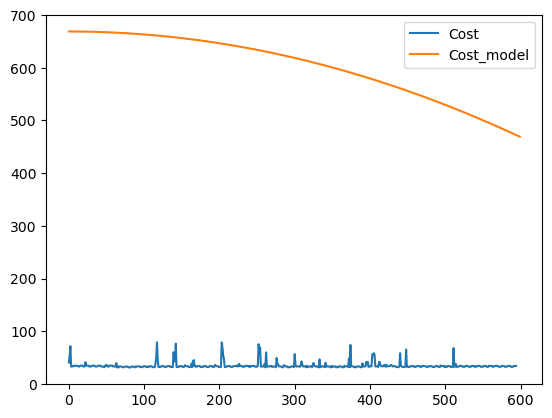

In [11]:
plt.plot(range(len(cost)),cost,label='Cost')
plt.plot((range(len(cost_thing))),cost_thing,label='Cost_model')
plt.legend()